<a href="https://colab.research.google.com/github/samuelamankwaa123/Growth_Analysis/blob/main/growth_analysis_ci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.
Running in local/Colab mode. Loading full dataset.
Full dataset shape: (22699, 18)
Engineered sample saved to sample_data.csv with shape (10000, 18)
Active dataset shape: (10000, 18)
       Unnamed: 0  VendorID    tpep_pickup_datetime   tpep_dropoff_datetime  \
9199    110047230         2   12/28/2017 3:16:22 PM   12/28/2017 3:35:38 PM   
4955    112175408         2   01/18/2017 7:17:06 AM   01/18/2017 7:22:10 AM   
16833    49968287         2   06/13/2017 3:58:32 PM   06/13/2017 4:17:11 PM   
13244    50110360         2  06/13/2017 11:01:33 PM  06/13/2017 11:24:45 PM   
1063     35472703         1  04/10/2017 10:42:24 PM  04/10/2017 10:53:55 PM   

       passenger_count  trip_distance  RatecodeID store_and_fwd_flag  \
9199                 1           1.30           1                  N   
4955                 1           1.20           1                  N   
16833                5           1.15           1                  N   
13244                

/tmp/ipykernel_639/188774003.py:83: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
/tmp/ipykernel_639/188774003.py:84: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")


Cleaned dataset shape: (9967, 20)

Merged hourly metrics:
   pickup_hour  trip_count  trip_duration_min  efficiency
0            0         354          11.852589   29.866891
1            1         225          11.266593   19.970545
2            2         172          11.319864   15.194528
3            3         124          11.717742   10.582244
4            4         121          11.981543   10.098866

Top 5 efficiency hours:
    pickup_hour  trip_count  trip_duration_min  efficiency
19           19         618          13.822600   44.709390
21           21         585          13.590541   43.044643
20           20         570          13.635292   41.803284
18           18         607          15.441571   39.309473
22           22         516          13.528973   38.140368


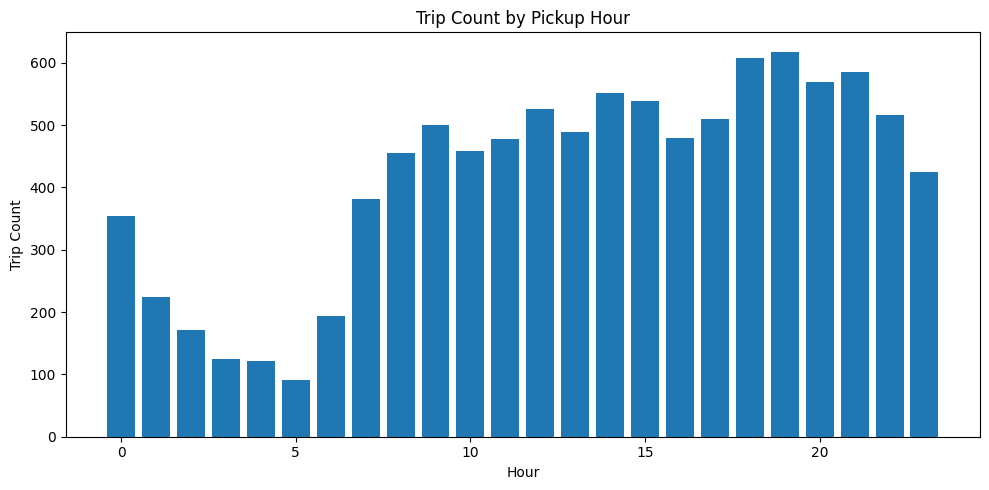

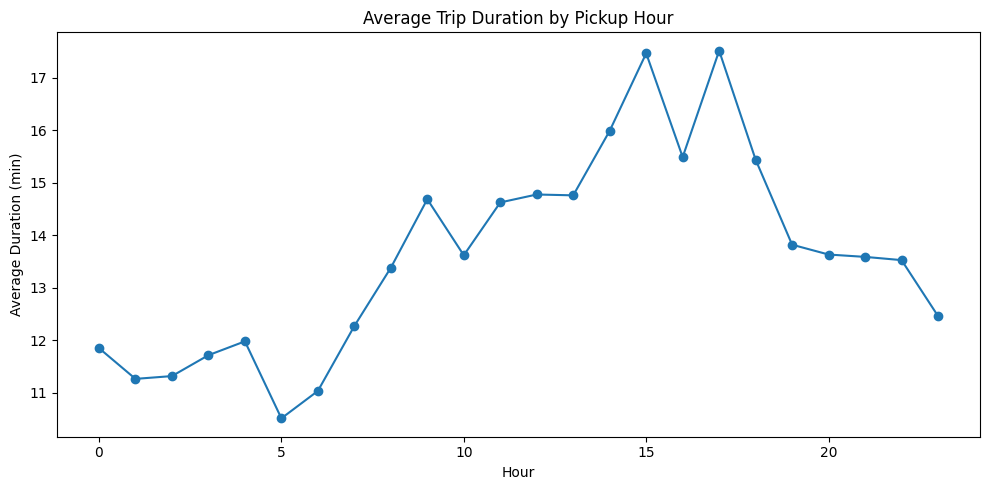

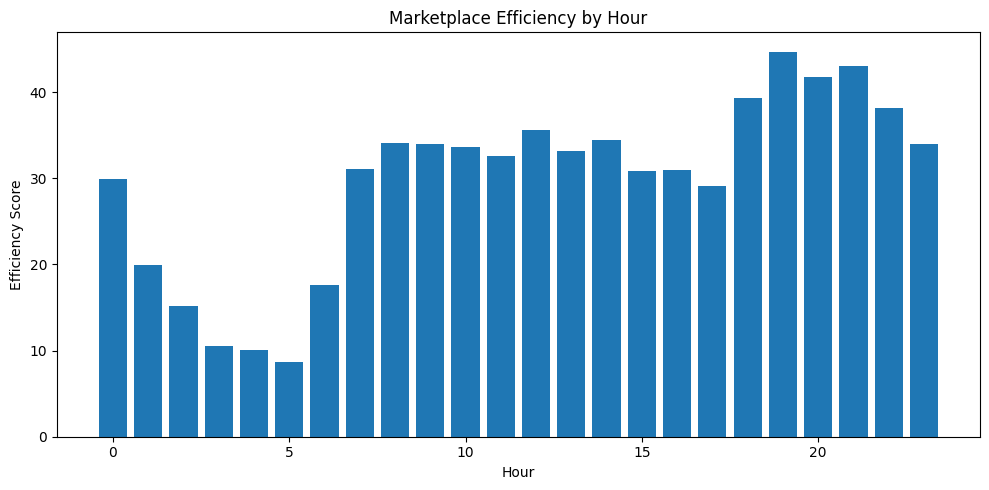

Saved hourly_growth_analysis_summary.csv
Notebook completed successfully.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

CI = os.getenv("CI", "false").lower() == "true"

full_file = "2017_Yellow_Taxi_Trip_Data.csv"
sample_file = "sample_data.csv"

# -------------------------
# Load or create sample
# -------------------------
if CI:
    if not os.path.exists(sample_file):
        raise FileNotFoundError(
            f"{sample_file} not found. Create it from the full dataset first and commit it to the repo."
        )
    print("Running in CI mode. Loading engineered sample.")
    df = pd.read_csv(sample_file)

else:
    if os.path.exists(full_file):
        print("Running in local/Colab mode. Loading full dataset.")
        df_full = pd.read_csv(full_file)

        print("Full dataset shape:", df_full.shape)

        # Engineer a manageable sample from the full dataset
        sample_size = min(10000, len(df_full))
        df = df_full.sample(n=sample_size, random_state=42).copy()

        # Save engineered sample for CI reuse
        df.to_csv(sample_file, index=False)
        print(f"Engineered sample saved to {sample_file} with shape {df.shape}")

    elif os.path.exists(sample_file):
        print("Full dataset not found. Falling back to sample.")
        df = pd.read_csv(sample_file)

    else:
        raise FileNotFoundError(
            f"Neither {full_file} nor {sample_file} was found."
        )

print("Active dataset shape:", df.shape)
print(df.head())

# -------------------------
# Normalize column names
# -------------------------
df.columns = [col.strip().lower() for col in df.columns]
print("Columns:", df.columns.tolist())

# -------------------------
# Detect datetime columns
# -------------------------
pickup_candidates = [
    "tpep_pickup_datetime",
    "pickup_datetime",
    "lpep_pickup_datetime"
]
dropoff_candidates = [
    "tpep_dropoff_datetime",
    "dropoff_datetime",
    "lpep_dropoff_datetime"
]

pickup_col = next((c for c in pickup_candidates if c in df.columns), None)
dropoff_col = next((c for c in dropoff_candidates if c in df.columns), None)

if pickup_col is None or dropoff_col is None:
    raise KeyError(
        f"Could not find pickup/dropoff datetime columns. Found columns: {df.columns.tolist()}"
    )

# -------------------------
# Basic cleaning
# -------------------------
df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")

df = df.dropna(subset=[pickup_col, dropoff_col]).copy()

df["trip_duration_min"] = (df[dropoff_col] - df[pickup_col]).dt.total_seconds() / 60
df = df[(df["trip_duration_min"] > 0) & (df["trip_duration_min"] < 300)].copy()

df["pickup_hour"] = df[pickup_col].dt.hour

print("Cleaned dataset shape:", df.shape)

# -------------------------
# Aggregations
# -------------------------
hourly_trip_count = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trip_count")
      .sort_values("pickup_hour")
)

hourly_duration = (
    df.groupby("pickup_hour")["trip_duration_min"]
      .mean()
      .reset_index()
      .sort_values("pickup_hour")
)

hourly_merged = pd.merge(
    hourly_trip_count,
    hourly_duration,
    on="pickup_hour",
    how="inner"
)

hourly_merged["efficiency"] = (
    hourly_merged["trip_count"] / hourly_merged["trip_duration_min"]
)

hourly_merged = hourly_merged.sort_values("pickup_hour").reset_index(drop=True)

print("\nMerged hourly metrics:")
print(hourly_merged.head())

print("\nTop 5 efficiency hours:")
print(hourly_merged.sort_values("efficiency", ascending=False).head())

# -------------------------
# Plots
# -------------------------
plt.figure(figsize=(10, 5))
plt.bar(hourly_merged["pickup_hour"], hourly_merged["trip_count"])
plt.title("Trip Count by Pickup Hour")
plt.xlabel("Hour")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.savefig("trip_count_by_hour.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hourly_merged["pickup_hour"], hourly_merged["trip_duration_min"], marker="o")
plt.title("Average Trip Duration by Pickup Hour")
plt.xlabel("Hour")
plt.ylabel("Average Duration (min)")
plt.tight_layout()
plt.savefig("trip_duration_by_hour.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(hourly_merged["pickup_hour"], hourly_merged["efficiency"])
plt.title("Marketplace Efficiency by Hour")
plt.xlabel("Hour")
plt.ylabel("Efficiency Score")
plt.tight_layout()
plt.savefig("efficiency_by_hour.png")
plt.show()

# -------------------------
# Save outputs
# -------------------------
hourly_merged.to_csv("hourly_growth_analysis_summary.csv", index=False)
print("Saved hourly_growth_analysis_summary.csv")

print("Notebook completed successfully.")